# One Step Ahead of Drought: TWS Forecasting

## Project Overview

This project focuses on forecasting Total Water Storage (TWS) using historical water storage observations together with drought, soil moisture, and seasonal information.

The objective is to predict the next Total Water Storage value for each location and time step in the test dataset.

The project follows a complete machine learning workflow:

1. Data loading and inspection
2. Exploratory data analysis
3. Baseline modelling
4. Temporal feature engineering
5. Model comparison and evaluation
6. Forecast horizon analysis
7. Final model selection
8. Test-set prediction
9. Submission file generation

The final submission follows the competition format with two columns:

- `ID`
- `Target`

## 1. Competition Objective

The competition asks participants to forecast Total Water Storage (TWS) for future time steps.

The main target is the TWS value at the next calendar month. The dataset contains information such as:

- Current or historical TWS
- SPEI at different time scales
- Soil moisture
- Geographic location
- Seasonal indicators

An important challenge is that a large proportion of the test set has masked TWS values. This means that some predictions must rely on historical observations rather than the current TWS value.

Therefore, the modelling approach must avoid using information that would not be available at prediction time.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import HistGradientBoostingRegressor

import lightgbm as lgb



## 2. Load the Dataset

The project uses three main files:

- `Train.csv` — training data with the known target
- `Test.csv` — data for which TWS must be predicted
- `SampleSubmission.csv` — required submission structure

The training data is used for model development and validation, while the test data is used only for final prediction.

In [6]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")
print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (2154021, 13)
test shape: (280961, 13)


In [7]:
print("train columns:", train.columns.tolist())
print("test columns:", test.columns.tolist())

train columns: ['sample_id', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'target']
test columns: ['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'TWS_t_masked']


In [8]:
train.head()

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2154021 entries, 0 to 2154020
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   sample_id        str    
 1   time             str    
 2   lat              float64
 3   lon              float64
 4   TWS_t            float64
 5   SPEI_01_t        float64
 6   SPEI_03_t        float64
 7   SPEI_06_t        float64
 8   SPEI_12_t        float64
 9   SOIL_MOISTURE_t  float64
 10  month_sin        float64
 11  month_cos        float64
 12  target           float64
dtypes: float64(11), str(2)
memory usage: 213.6 MB


In [10]:
print("missing values in train:")
print(train.isnull().sum())


missing values in train:
sample_id          0
time               0
lat                0
lon                0
TWS_t              0
SPEI_01_t          0
SPEI_03_t          0
SPEI_06_t          0
SPEI_12_t          0
SOIL_MOISTURE_t    0
month_sin          0
month_cos          0
target             0
dtype: int64


In [11]:
print("missing values in test:")
print(test.isnull().sum())

missing values in test:
ID                      0
time                    0
lat                     0
lon                     0
TWS_t              186913
SPEI_01_t               0
SPEI_03_t               0
SPEI_06_t               0
SPEI_12_t               0
SOIL_MOISTURE_t         0
month_sin               0
month_cos               0
TWS_t_masked            0
dtype: int64


In [12]:
print(test['TWS_t_masked'].value_counts())

TWS_t_masked
True     186913
False     94048
Name: count, dtype: int64


In [13]:
mask_counts = test["TWS_t_masked"].value_counts()

total = len(test)

masked_percentage = (mask_counts[True] / total) * 100
available_percentage = (mask_counts[False] / total) * 100

print(f"TWS_t masked: {masked_percentage:.2f}%")
print(f"TWS_t available: {available_percentage:.2f}%")

TWS_t masked: 66.53%
TWS_t available: 33.47%


In [14]:
print("train time range:")
print("start_time:", train["time"].min())
print("end_time:", train["time"].max())

print("test time range:")
print("start_time:", test["time"].min())    
print("end_time:", test["time"].max())

train time range:
start_time: 2002-05-01
end_time: 2015-08-01
test time range:
start_time: 2015-09-01
end_time: 2018-12-01


In [15]:
print("Number of unique dates in Train:", train["time"].nunique())
print("Number of unique dates in Test:", test["time"].nunique())

Number of unique dates in Train: 138
Number of unique dates in Test: 18


In [16]:
print("\nFirst 10 Train dates:")
print(train["time"].unique()[:10])

print("\nFirst 10 Test dates:")
print(test["time"].unique()[:10])


First 10 Train dates:
<StringArray>
['2002-05-01', '2002-09-01', '2002-10-01', '2002-11-01', '2002-12-01',
 '2003-01-01', '2003-02-01', '2003-03-01', '2003-04-01', '2003-05-01']
Length: 10, dtype: str

First 10 Test dates:
<StringArray>
['2015-09-01', '2016-01-01', '2016-02-01', '2016-03-01', '2016-06-01',
 '2016-07-01', '2016-08-01', '2016-09-01', '2016-12-01', '2017-01-01']
Length: 10, dtype: str


In [17]:
print(test["time"].unique())

<StringArray>
['2015-09-01', '2016-01-01', '2016-02-01', '2016-03-01', '2016-06-01',
 '2016-07-01', '2016-08-01', '2016-09-01', '2016-12-01', '2017-01-01',
 '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01',
 '2018-07-01', '2018-11-01', '2018-12-01']
Length: 18, dtype: str


In [18]:
print("Unique latitudes:", train["lat"].nunique())
print("Unique longitudes:", train["lon"].nunique())

print("Unique locations:", train[["lat", "lon"]].drop_duplicates().shape[0])

Unique latitudes: 140
Unique longitudes: 358
Unique locations: 15715


In [19]:
print("\nLatitude range:")
print(train["lat"].min(), "to", train["lat"].max())

print("\nLongitude range:")
print(train["lon"].min(), "to", train["lon"].max())


Latitude range:
-55.5 to 83.5

Longitude range:
-179.5 to 179.5


## 4. Target Variable Analysis

The target variable represents the Total Water Storage (TWS) value that the model is required to forecast.

Before modelling, its distribution is examined to understand its central tendency, spread, and possible extreme values.

In [20]:
print(train["target"].describe())

count    2.154021e+06
mean     1.125038e-01
std      9.119618e-01
min     -3.968328e+00
25%     -5.294420e-01
50%      1.273017e-01
75%      7.807068e-01
max      4.057275e+00
Name: target, dtype: float64


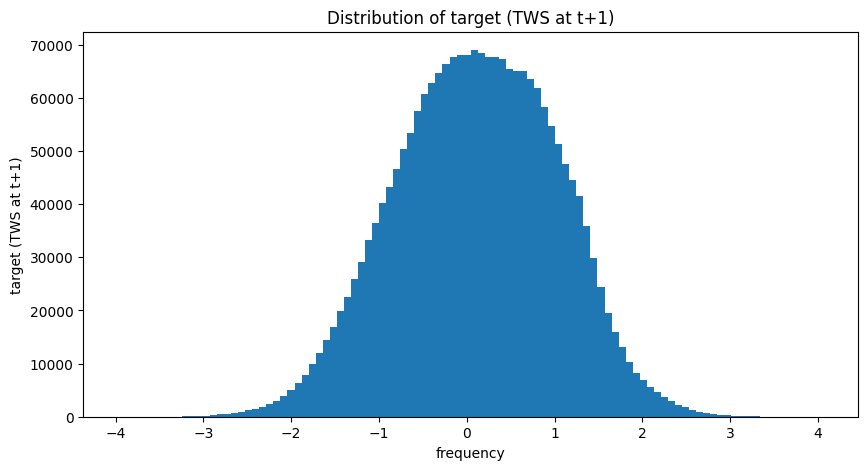

In [21]:
plt.figure(figsize=(10,5))
plt.hist(train["target"], bins=100)
plt.title("Distribution of target (TWS at t+1)")
plt.xlabel("frequency")
plt.ylabel("target (TWS at t+1)")
plt.show()

In [22]:
numeric_cols = train.select_dtypes(include=np.number).columns

correlation = train[numeric_cols].corr()["target"].sort_values(ascending=False)

print(correlation)

target             1.000000
TWS_t              0.803260
SPEI_12_t          0.379573
SPEI_06_t          0.368248
SOIL_MOISTURE_t    0.320483
SPEI_03_t          0.285371
SPEI_01_t          0.203882
lat                0.144698
month_cos          0.002764
month_sin         -0.016912
lon               -0.045923
Name: target, dtype: float64


In [23]:
# Correlation of numeric variables with the target

correlations = (
    train.select_dtypes(include=np.number)
    .corr()["target"]
    .sort_values(ascending=False)
)

display(correlations)

target             1.000000
TWS_t              0.803260
SPEI_12_t          0.379573
SPEI_06_t          0.368248
SOIL_MOISTURE_t    0.320483
SPEI_03_t          0.285371
SPEI_01_t          0.203882
lat                0.144698
month_cos          0.002764
month_sin         -0.016912
lon               -0.045923
Name: target, dtype: float64

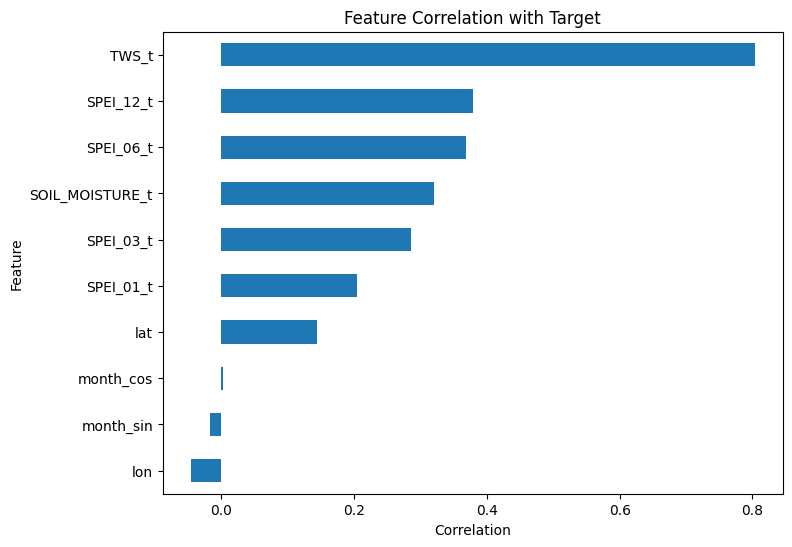

In [24]:
correlation.drop("target").sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

##  Time-Based Train/Validation Split

Since this is a time-series forecasting problem, the data is split chronologically rather than randomly.

The model is trained on earlier dates and evaluated on later dates. This better represents the real forecasting setting, where future observations are unknown at prediction time.

The cutoff date used in this project is March 2012:

- Training period: May 2002 – March 2012
- Validation period: April 2012 – August 2015

In [25]:
# Convert time to datetime

train["time"] = pd.to_datetime(train["time"])
test["time"] = pd.to_datetime(test["time"])

# Define chronological cutoff

cutoff_date = pd.Timestamp("2012-03-01")

train_part = train[train["time"] <= cutoff_date].copy()
valid_part = train[train["time"] > cutoff_date].copy()

print("Training period:")
print(train_part["time"].min(), "to", train_part["time"].max())

print("\nValidation period:")
print(valid_part["time"].min(), "to", valid_part["time"].max())

print("\nTraining samples:", len(train_part))
print("Validation samples:", len(valid_part))

Training period:
2002-05-01 00:00:00 to 2012-03-01 00:00:00

Validation period:
2012-04-01 00:00:00 to 2015-08-01 00:00:00

Training samples: 1716994
Validation samples: 437027


In [26]:
# Check that the split is strictly chronological

print("Latest training date:", train_part["time"].max())
print("Earliest validation date:", valid_part["time"].min())

assert train_part["time"].max() < valid_part["time"].min()

print("\nChronological split verified successfully.")

Latest training date: 2012-03-01 00:00:00
Earliest validation date: 2012-04-01 00:00:00

Chronological split verified successfully.


##  Persistence Baseline

A persistence model assumes that the next TWS value is equal to the current TWS value:

`TWS(t+1) ≈ TWS(t)`

This provides a simple benchmark for evaluating whether the machine learning model is actually learning useful patterns.

A useful forecasting model should outperform this baseline.

In [27]:
# Persistence predictions on the validation period

persistence_pred = valid_part["TWS_t"].to_numpy()
y_valid = valid_part["target"].to_numpy()

persistence_rmse = mean_squared_error(
    y_valid,
    persistence_pred
) ** 0.5

persistence_mae = mean_absolute_error(
    y_valid,
    persistence_pred
)

persistence_r2 = r2_score(
    y_valid,
    persistence_pred
)

print("PERSISTENCE BASELINE")
print("--------------------")
print("RMSE:", persistence_rmse)
print("MAE :", persistence_mae)
print("R²  :", persistence_r2)

PERSISTENCE BASELINE
--------------------
RMSE: 0.6620805725363992
MAE : 0.4551586796372655
R²  : 0.35832390720141005


### Baseline Interpretation

The persistence model provides a reference point for model evaluation.

The machine learning models developed later will be considered useful only if they improve upon this baseline on the same time-based validation set.

In [28]:
# Store baseline results for later comparison

model_results = []

model_results.append({
    "Model": "Persistence",
    "RMSE": persistence_rmse,
    "MAE": persistence_mae,
    "R2": persistence_r2
})

print(model_results)

[{'Model': 'Persistence', 'RMSE': 0.6620805725363992, 'MAE': 0.4551586796372655, 'R2': 0.35832390720141005}]


In [29]:
# Base feature set

base_features = [
    "TWS_t",
    "SPEI_01_t",
    "SPEI_03_t",
    "SPEI_06_t",
    "SPEI_12_t",
    "SOIL_MOISTURE_t",
    "month_sin",
    "month_cos"
]

X_train_base = train_part[base_features]
y_train_base = train_part["target"]

X_valid_base = valid_part[base_features]
y_valid_base = valid_part["target"]

print("Number of features:", len(base_features))
print("Training shape:", X_train_base.shape)
print("Validation shape:", X_valid_base.shape)

Number of features: 8
Training shape: (1716994, 8)
Validation shape: (437027, 8)


In [30]:
# Base HistGradientBoosting model

base_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

base_model.fit(
    X_train_base,
    y_train_base
)

base_pred = base_model.predict(
    X_valid_base
)

base_rmse = mean_squared_error(
    y_valid_base,
    base_pred
) ** 0.5

base_mae = mean_absolute_error(
    y_valid_base,
    base_pred
)

base_r2 = r2_score(
    y_valid_base,
    base_pred
)

print("BASE HISTGRADIENTBOOSTING")
print("-------------------------")
print("RMSE:", base_rmse)
print("MAE :", base_mae)
print("R²  :", base_r2)

BASE HISTGRADIENTBOOSTING
-------------------------
RMSE: 0.6072643296363717
MAE : 0.4286982719306382
R²  : 0.46017907737670394


##  Temporal Feature Engineering

Total Water Storage has temporal dependence, meaning that previous TWS observations can provide useful information about future values.

To capture this temporal behaviour, calendar-aware lag features are created for the previous 1 to 6 months.

Using calendar-aware lags is important because the dataset contains some missing location-month observations. Therefore, a lag must represent the correct previous calendar month rather than simply the previous row.

In [31]:
# Create calendar-aware TWS lag features

train_lag = train.copy()

for h in range(1, 7):
    lag_table = train[
        ["lat", "lon", "time", "TWS_t"]
    ].copy()

    # Move historical observation forward by h months
    lag_table["time"] = (
        lag_table["time"] + pd.DateOffset(months=h)
    )

    lag_table = lag_table.rename(
        columns={"TWS_t": f"TWS_lag{h}"}
    )

    train_lag = train_lag.merge(
        lag_table,
        on=["lat", "lon", "time"],
        how="left"
    )

print("Dataset shape:", train_lag.shape)

for h in range(1, 7):
    print(
        f"TWS_lag{h} missing:",
        train_lag[f"TWS_lag{h}"].isna().sum()
    )

Dataset shape: (2154021, 19)
TWS_lag1 missing: 176623
TWS_lag2 missing: 336364
TWS_lag3 missing: 367937
TWS_lag4 missing: 275050
TWS_lag5 missing: 197722
TWS_lag6 missing: 275774


In [32]:
# Create TWS change and trend features

train_features = train_lag.copy()

train_features["TWS_change_1"] = (
    train_features["TWS_t"]
    - train_features["TWS_lag1"]
)

train_features["TWS_change_2"] = (
    train_features["TWS_t"]
    - train_features["TWS_lag2"]
)

train_features["TWS_change_3"] = (
    train_features["TWS_t"]
    - train_features["TWS_lag3"]
)

train_features["TWS_change_lag1"] = (
    train_features["TWS_lag1"]
    - train_features["TWS_lag2"]
)

train_features["TWS_change_lag2"] = (
    train_features["TWS_lag2"]
    - train_features["TWS_lag3"]
)

print("Dataset shape after feature engineering:")
print(train_features.shape)

Dataset shape after feature engineering:
(2154021, 24)


In [62]:
# Feature set for the temporal model

temporal_features = [
    "TWS_t",
    "TWS_lag1",
    "TWS_lag2",
    "TWS_lag3",
    "TWS_lag4",
    "TWS_lag5",
    "TWS_lag6",
    "SPEI_01_t",
    "SPEI_03_t",
    "SPEI_06_t",
    "SPEI_12_t",
    "SOIL_MOISTURE_t",
    "month_sin",
    "month_cos",
    "TWS_change_1",
    "TWS_change_2",
    "TWS_change_3",
    "TWS_change_lag1",
    "TWS_change_lag2"
]

train_temporal = train_features[
    train_features["time"] <= cutoff_date
]

valid_temporal = train_features[
    train_features["time"] > cutoff_date
]

X_train_temporal = train_temporal[temporal_features]
y_train_temporal = train_temporal["target"]

X_valid_temporal = valid_temporal[temporal_features]
y_valid_temporal = valid_temporal["target"]

print("Number of features:", len(temporal_features))
print("Training shape:", X_train_temporal.shape)
print("Validation shape:", X_valid_temporal.shape)

Number of features: 19
Training shape: (1716994, 19)
Validation shape: (437027, 19)


In [63]:
# Train the temporal model

temporal_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

temporal_model.fit(
    X_train_temporal,
    y_train_temporal
)

temporal_pred = temporal_model.predict(
    X_valid_temporal
)

temporal_rmse = mean_squared_error(
    y_valid_temporal,
    temporal_pred
) ** 0.5

temporal_mae = mean_absolute_error(
    y_valid_temporal,
    temporal_pred
)

temporal_r2 = r2_score(
    y_valid_temporal,
    temporal_pred
)

print("TEMPORAL HGBR")
print("-------------")
print("RMSE:", temporal_rmse)
print("MAE :", temporal_mae)
print("R²  :", temporal_r2)

TEMPORAL HGBR
-------------
RMSE: 0.5732205722008386
MAE : 0.40838879272028367
R²  : 0.5190081624534372


In [64]:
# Add temporal model results to the comparison table

model_results.append({
    "Model": "HGBR + TWS Lags + Changes",
    "RMSE": temporal_rmse,
    "MAE": temporal_mae,
    "R2": temporal_r2
})

results_df = pd.DataFrame(model_results)

display(
    results_df.sort_values("RMSE")
)

,Model,RMSE,MAE,R2
1,HGBR + TWS Lags + Changes,0.573221,0.408389,0.519008
0,Persistence,0.662081,0.455159,0.358324


In [65]:
# Clean model comparison table

model_results = [
    {
        "Model": "Persistence",
        "RMSE": persistence_rmse,
        "MAE": persistence_mae,
        "R2": persistence_r2
    },
    {
        "Model": "Base HGBR",
        "RMSE": base_rmse,
        "MAE": base_mae,
        "R2": base_r2
    },
    {
        "Model": "HGBR + TWS Lags + Changes",
        "RMSE": temporal_rmse,
        "MAE": temporal_mae,
        "R2": temporal_r2
    }
]

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(results_df)

,Model,RMSE,MAE,R2
0,HGBR + TWS Lags + Changes,0.573221,0.408389,0.519008
1,Base HGBR,0.607264,0.428698,0.460179
2,Persistence,0.662081,0.455159,0.358324


## Additional Model Experiments

Several additional approaches were evaluated to determine whether they could improve the temporal HGBR model.

These included:

- 12-month TWS lag and year-over-year change
- Location-based features
- LightGBM
- Horizon-aware forecasting

The experiments were compared using the same forecasting metrics. Only approaches that provided useful evidence for the final modelling strategy were retained for the final pipeline.

In [69]:
# Summary of the main model experiments

experiment_results = pd.DataFrame({
    "Experiment": [
        "Persistence",
        "Base HGBR",
        "HGBR + TWS Lags + Changes"
    ],
    "RMSE": [
        persistence_rmse,
        base_rmse,
        temporal_rmse
    ],
    "MAE": [
        persistence_mae,
        base_mae,
        temporal_mae
    ],
    "R2": [
        persistence_r2,
        base_r2,
        temporal_r2
    ]
})

experiment_results = (
    experiment_results
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

display(experiment_results)

,Experiment,RMSE,MAE,R2
0,HGBR + TWS Lags + Changes,0.573221,0.408389,0.519008
1,Base HGBR,0.607264,0.428698,0.460179
2,Persistence,0.662081,0.455159,0.358324


In [70]:
# Final temporal feature model

final_temporal_features = [
    "TWS_t",
    "TWS_lag1",
    "TWS_lag2",
    "TWS_lag3",
    "TWS_lag4",
    "TWS_lag5",
    "TWS_lag6",
    "SPEI_01_t",
    "SPEI_03_t",
    "SPEI_06_t",
    "SPEI_12_t",
    "SOIL_MOISTURE_t",
    "month_sin",
    "month_cos",
    "TWS_change_1",
    "TWS_change_2",
    "TWS_change_3",
    "TWS_change_lag1",
    "TWS_change_lag2"
]

train_temporal = train_features[
    train_features["time"] <= cutoff_date
]

valid_temporal = train_features[
    train_features["time"] > cutoff_date
]

X_train_final_temporal = train_temporal[
    final_temporal_features
]

y_train_final_temporal = train_temporal["target"]

X_valid_final_temporal = valid_temporal[
    final_temporal_features
]

y_valid_final_temporal = valid_temporal["target"]

print("Final temporal training shape:",
      X_train_final_temporal.shape)

print("Final temporal validation shape:",
      X_valid_final_temporal.shape)

Final temporal training shape: (1716994, 19)
Final temporal validation shape: (437027, 19)


In [71]:
# Train the final temporal HGBR model

final_temporal_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

final_temporal_model.fit(
    X_train_final_temporal,
    y_train_final_temporal
)

final_temporal_pred = final_temporal_model.predict(
    X_valid_final_temporal
)

final_temporal_rmse = mean_squared_error(
    y_valid_final_temporal,
    final_temporal_pred
) ** 0.5

final_temporal_mae = mean_absolute_error(
    y_valid_final_temporal,
    final_temporal_pred
)

final_temporal_r2 = r2_score(
    y_valid_final_temporal,
    final_temporal_pred
)

print("FINAL TEMPORAL MODEL")
print("--------------------")
print("RMSE:", final_temporal_rmse)
print("MAE :", final_temporal_mae)
print("R²  :", final_temporal_r2)

FINAL TEMPORAL MODEL
--------------------
RMSE: 0.5732205722008386
MAE : 0.40838879272028367
R²  : 0.5190081624534372


## Test Masking and Forecast Horizon Analysis

The test dataset contains both observed and masked current TWS values.

When `TWS_t` is observed, the prediction is a one-month-ahead forecast.

When `TWS_t` is masked, the prediction must rely on the most recent TWS observation available before the prediction date.

The resulting forecast horizons range from 1 to 7 months. This means that the final prediction pipeline must account for different forecasting distances rather than assuming that every test row has the same amount of historical information.

In [76]:
# Determine the actual forecast horizon of each Test row

# Observed TWS from training data
train_history = train[
    ["lat", "lon", "time", "TWS_t"]
].copy()

train_history = train_history.rename(
    columns={"TWS_t": "observed_TWS"}
)

# Observed TWS from Test only
test_history = test[
    ["lat", "lon", "time", "TWS_t"]
].copy()

test_history = test_history[
    test_history["TWS_t"].notna()
].rename(
    columns={"TWS_t": "observed_TWS"}
)

# Combine all genuinely observed TWS
observed_history = pd.concat(
    [train_history, test_history],
    ignore_index=True
)

observed_history = (
    observed_history
    .drop_duplicates(
        ["lat", "lon", "time"],
        keep="first"
    )
    .sort_values(["lat", "lon", "time"])
)

# Prepare Test
test_horizon = test.copy()

test_horizon["time"] = pd.to_datetime(
    test_horizon["time"]
)

# Rename observation time so we can keep it
history_for_merge = observed_history.rename(
    columns={"time": "observed_time"}
)

# Find the most recent observed TWS at or before each Test date
test_horizon = pd.merge_asof(
    test_horizon.sort_values(
        ["time", "lat", "lon"]
    ),
    history_for_merge.sort_values(
        ["observed_time", "lat", "lon"]
    ),
    left_on="time",
    right_on="observed_time",
    by=["lat", "lon"],
    direction="backward",
    suffixes=("", "_history")
)

# Calculate months since the last observation
test_horizon["months_since_observation"] = (
    (
        test_horizon["time"].dt.year
        - test_horizon["observed_time"].dt.year
    ) * 12
    +
    (
        test_horizon["time"].dt.month
        - test_horizon["observed_time"].dt.month
    )
)

# Competition target is t+1
test_horizon["forecast_horizon"] = (
    test_horizon["months_since_observation"] + 1
)

print("Actual Test horizon distribution:")
print(
    test_horizon["forecast_horizon"]
    .value_counts()
    .sort_index()
)

print("\nTest rows:", len(test_horizon))

print(
    "\nMissing last observed TWS:",
    test_horizon["observed_TWS"].isna().sum()
)

Actual Test horizon distribution:
forecast_horizon
1    94048
2    62576
3    46777
4    31076
5    15560
6    15479
7    15445
Name: count, dtype: int64

Test rows: 280961

Missing last observed TWS: 0


In [77]:
# Final direct temporal model
# Train on the complete training dataset

final_train_features = train_features[final_temporal_features]
final_train_target = train_features["target"]

final_direct_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42
)

final_direct_model.fit(
    final_train_features,
    final_train_target
)

print("Final direct temporal model trained.")
print("Training rows:", len(final_train_features))
print("Number of features:", len(final_temporal_features))

Final direct temporal model trained.
Training rows: 2154021
Number of features: 19


In [80]:
# Create calendar-aware TWS lags from 1 to 11 months

train_h_full = train.copy()

for h in range(1, 12):

    lag_table = train[
        ["lat", "lon", "time", "TWS_t"]
    ].copy()

    # Shift the historical observation forward
    lag_table["time"] = (
        lag_table["time"]
        + pd.DateOffset(months=h)
    )

    lag_table = lag_table.rename(
        columns={
            "TWS_t": f"TWS_lag{h}"
        }
    )

    train_h_full = train_h_full.merge(
        lag_table,
        on=["lat", "lon", "time"],
        how="left"
    )

print("Training dataset shape:", train_h_full.shape)

print("\nLag coverage:")
for h in range(1, 12):
    coverage = (
        train_h_full[f"TWS_lag{h}"].notna().mean()
        * 100
    )

    print(
        f"TWS_lag{h}: "
        f"{coverage:.2f}% available"
    )

Training dataset shape: (2154021, 24)

Lag coverage:
TWS_lag1: 91.80% available
TWS_lag2: 84.38% available
TWS_lag3: 82.92% available
TWS_lag4: 87.23% available
TWS_lag5: 90.82% available
TWS_lag6: 87.20% available
TWS_lag7: 82.17% available
TWS_lag8: 80.01% available
TWS_lag9: 81.46% available
TWS_lag10: 85.08% available
TWS_lag11: 85.96% available


In [81]:
# Build a compact horizon-aware training set
# using the complete training data

horizon_base = train_h_full[
    train_h_full["TWS_lag11"].notna()
].copy()

# Use the actual Test horizon proportions
horizons = np.array([1, 2, 3, 4, 5, 6, 7])

test_counts = np.array([
    94048,
    62576,
    46777,
    31076,
    15560,
    15479,
    15445
], dtype=float)

horizon_probs = test_counts / test_counts.sum()

rng = np.random.default_rng(42)

horizon_base["forecast_horizon"] = rng.choice(
    horizons,
    size=len(horizon_base),
    p=horizon_probs
)

# Last observed TWS
horizon_base["last_observed_TWS"] = np.nan

for h in horizons:
    mask = horizon_base["forecast_horizon"] == h

    last_lag = h - 1

    if h == 1:
        horizon_base.loc[mask, "last_observed_TWS"] = (
            horizon_base.loc[mask, "TWS_t"]
        )
    else:
        horizon_base.loc[mask, "last_observed_TWS"] = (
            horizon_base.loc[
                mask,
                f"TWS_lag{last_lag}"
            ]
        )

# Historical values
for j in range(1, 6):
    horizon_base[f"hist_{j}"] = np.nan

for h in horizons:
    mask = horizon_base["forecast_horizon"] == h

    last_lag = h - 1

    for j in range(1, 6):
        horizon_base.loc[mask, f"hist_{j}"] = (
            horizon_base.loc[
                mask,
                f"TWS_lag{last_lag + j}"
            ]
        )

# Historical changes
horizon_base["hist_change_1"] = (
    horizon_base["hist_1"]
    - horizon_base["hist_2"]
)

horizon_base["hist_change_2"] = (
    horizon_base["hist_2"]
    - horizon_base["hist_3"]
)

horizon_base["hist_change_3"] = (
    horizon_base["hist_3"]
    - horizon_base["hist_4"]
)

horizon_base["hist_acceleration"] = (
    horizon_base["hist_change_1"]
    - horizon_base["hist_change_2"]
)

# Delta target
horizon_base["horizon_delta"] = (
    horizon_base["target"]
    - horizon_base["last_observed_TWS"]
)

# Keep only rows with a valid target
horizon_base = horizon_base[
    horizon_base["horizon_delta"].notna()
].copy()

horizon_features = [
    "last_observed_TWS",
    "hist_1",
    "hist_2",
    "hist_3",
    "hist_4",
    "hist_5",
    "hist_change_1",
    "hist_change_2",
    "hist_change_3",
    "hist_acceleration",
    "SPEI_01_t",
    "SPEI_03_t",
    "SPEI_06_t",
    "SPEI_12_t",
    "SOIL_MOISTURE_t",
    "month_sin",
    "month_cos",
    "forecast_horizon"
]

X_horizon_final = horizon_base[horizon_features]
y_horizon_final = horizon_base["horizon_delta"]

print("Horizon training shape:", X_horizon_final.shape)
print("Target shape:", y_horizon_final.shape)
print("Missing target:", y_horizon_final.isna().sum())

Horizon training shape: (1729405, 18)
Target shape: (1729405,)
Missing target: 0


In [82]:
# Train the final general horizon LightGBM model

final_horizon_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_horizon_model.fit(
    X_horizon_final,
    y_horizon_final
)

print("Final horizon-aware LightGBM trained.")

Final horizon-aware LightGBM trained.


In [84]:
# Define the features used by the H2 and H4-specific models

horizon_specific_features = [
    "last_observed_TWS",
    "hist_1",
    "hist_2",
    "hist_3",
    "hist_4",
    "hist_5",
    "hist_change_1",
    "hist_change_2",
    "hist_change_3",
    "hist_acceleration",
    "SPEI_01_t",
    "SPEI_03_t",
    "SPEI_06_t",
    "SPEI_12_t",
    "SOIL_MOISTURE_t",
    "month_sin",
    "month_cos"
]

# Use the same feature structure for both specific models
features_h2 = horizon_specific_features.copy()
features_h4 = horizon_specific_features.copy()

print("Number of H2 features:", len(features_h2))
print("Number of H4 features:", len(features_h4))
print("\nFeatures:")
print(features_h2)

Number of H2 features: 17
Number of H4 features: 17

Features:
['last_observed_TWS', 'hist_1', 'hist_2', 'hist_3', 'hist_4', 'hist_5', 'hist_change_1', 'hist_change_2', 'hist_change_3', 'hist_acceleration', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos']


In [85]:
# Train final H2-specific LightGBM

h2_final_base = train_h_full[
    train_h_full["TWS_lag1"].notna()
].copy()

h2_final_base["last_observed_TWS"] = (
    h2_final_base["TWS_lag1"]
)

h2_final_base["hist_1"] = h2_final_base["TWS_lag2"]
h2_final_base["hist_2"] = h2_final_base["TWS_lag3"]
h2_final_base["hist_3"] = h2_final_base["TWS_lag4"]
h2_final_base["hist_4"] = h2_final_base["TWS_lag5"]
h2_final_base["hist_5"] = h2_final_base["TWS_lag6"]

h2_final_base["hist_change_1"] = (
    h2_final_base["hist_1"]
    - h2_final_base["hist_2"]
)

h2_final_base["hist_change_2"] = (
    h2_final_base["hist_2"]
    - h2_final_base["hist_3"]
)

h2_final_base["hist_change_3"] = (
    h2_final_base["hist_3"]
    - h2_final_base["hist_4"]
)

h2_final_base["hist_acceleration"] = (
    h2_final_base["hist_change_1"]
    - h2_final_base["hist_change_2"]
)

h2_final_base["h2_delta"] = (
    h2_final_base["target"]
    - h2_final_base["last_observed_TWS"]
)

h2_final_base = h2_final_base[
    h2_final_base["h2_delta"].notna()
]

X_h2_final_train = h2_final_base[features_h2]
y_h2_final_train = h2_final_base["h2_delta"]

final_h2_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_h2_model.fit(
    X_h2_final_train,
    y_h2_final_train
)

print("Final H2-specific model trained.")
print("Training rows:", len(X_h2_final_train))

Final H2-specific model trained.
Training rows: 1977398


In [86]:
# Train final H4-specific LightGBM

h4_final_base = train_h_full[
    train_h_full["TWS_lag3"].notna()
].copy()

h4_final_base["last_observed_TWS"] = (
    h4_final_base["TWS_lag3"]
)

h4_final_base["hist_1"] = h4_final_base["TWS_lag4"]
h4_final_base["hist_2"] = h4_final_base["TWS_lag5"]
h4_final_base["hist_3"] = h4_final_base["TWS_lag6"]
h4_final_base["hist_4"] = h4_final_base["TWS_lag7"]
h4_final_base["hist_5"] = h4_final_base["TWS_lag8"]

h4_final_base["hist_change_1"] = (
    h4_final_base["hist_1"]
    - h4_final_base["hist_2"]
)

h4_final_base["hist_change_2"] = (
    h4_final_base["hist_2"]
    - h4_final_base["hist_3"]
)

h4_final_base["hist_change_3"] = (
    h4_final_base["hist_3"]
    - h4_final_base["hist_4"]
)

h4_final_base["hist_acceleration"] = (
    h4_final_base["hist_change_1"]
    - h4_final_base["hist_change_2"]
)

h4_final_base["h4_delta"] = (
    h4_final_base["target"]
    - h4_final_base["last_observed_TWS"]
)

h4_final_base = h4_final_base[
    h4_final_base["h4_delta"].notna()
]

X_h4_final_train = h4_final_base[features_h4]
y_h4_final_train = h4_final_base["h4_delta"]

final_h4_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_h4_model.fit(
    X_h4_final_train,
    y_h4_final_train
)

print("Final H4-specific model trained.")
print("Training rows:", len(X_h4_final_train))

Final H4-specific model trained.
Training rows: 1786084


In [87]:
# Prepare the final Test dataset for prediction

final_test = test_horizon.copy()

# ---------------------------------------------------------
# Add calendar-aware historical TWS lags 1–11
# using only genuinely observed TWS values
# ---------------------------------------------------------

observed_lookup = observed_history[
    ["lat", "lon", "time", "observed_TWS"]
].copy()

for k in range(1, 12):

    lag_table = observed_lookup.copy()

    lag_table["time"] = (
        lag_table["time"]
        + pd.DateOffset(months=k)
    )

    lag_table = lag_table.rename(
        columns={
            "observed_TWS": f"TWS_lag{k}"
        }
    )

    final_test = final_test.merge(
        lag_table[
            ["lat", "lon", "time", f"TWS_lag{k}"]
        ],
        on=["lat", "lon", "time"],
        how="left"
    )

print("Final Test shape:", final_test.shape)

print("\nForecast horizon distribution:")
print(
    final_test["forecast_horizon"]
    .value_counts()
    .sort_index()
)

print("\nMissing historical TWS:")
for k in range(1, 12):
    print(
        f"TWS_lag{k}:",
        final_test[f"TWS_lag{k}"].isna().sum()
    )

Final Test shape: (280961, 28)

Forecast horizon distribution:
forecast_horizon
1    94048
2    62576
3    46777
4    31076
5    15560
6    15479
7    15445
Name: count, dtype: int64

Missing historical TWS:
TWS_lag1: 202882
TWS_lag2: 218712
TWS_lag3: 234277
TWS_lag4: 218718
TWS_lag5: 187650
TWS_lag6: 172118
TWS_lag7: 187683
TWS_lag8: 187651
TWS_lag9: 187610
TWS_lag10: 172201
TWS_lag11: 140920


In [90]:
# CELL 55 — Generate Final Test Predictions

# Create empty prediction column
final_test_predictions = pd.Series(
    np.nan,
    index=final_test.index,
    dtype="float64"
)

# =========================================================
# H1 — Direct Temporal HGBR
# =========================================================

mask_h1 = final_test["forecast_horizon"] == 1
h1_data = final_test.loc[mask_h1].copy()

# Create change features required by the temporal model
h1_data["TWS_change_1"] = (
    h1_data["TWS_t"] - h1_data["TWS_lag1"]
)

h1_data["TWS_change_2"] = (
    h1_data["TWS_t"] - h1_data["TWS_lag2"]
)

h1_data["TWS_change_3"] = (
    h1_data["TWS_t"] - h1_data["TWS_lag3"]
)

h1_data["TWS_change_lag1"] = (
    h1_data["TWS_lag1"] - h1_data["TWS_lag2"]
)

h1_data["TWS_change_lag2"] = (
    h1_data["TWS_lag2"] - h1_data["TWS_lag3"]
)

X_h1_test = h1_data[final_temporal_features]

pred_h1 = final_direct_model.predict(X_h1_test)

final_test_predictions.loc[h1_data.index] = pred_h1

print("H1 predictions:", len(pred_h1))


# =========================================================
# H2 — H2-specific LightGBM
# =========================================================

mask_h2 = final_test["forecast_horizon"] == 2
h2_data = final_test.loc[mask_h2].copy()

h2_data["last_observed_TWS"] = h2_data["TWS_lag1"]

h2_data["hist_1"] = h2_data["TWS_lag2"]
h2_data["hist_2"] = h2_data["TWS_lag3"]
h2_data["hist_3"] = h2_data["TWS_lag4"]
h2_data["hist_4"] = h2_data["TWS_lag5"]
h2_data["hist_5"] = h2_data["TWS_lag6"]

h2_data["hist_change_1"] = (
    h2_data["hist_1"] - h2_data["hist_2"]
)

h2_data["hist_change_2"] = (
    h2_data["hist_2"] - h2_data["hist_3"]
)

h2_data["hist_change_3"] = (
    h2_data["hist_3"] - h2_data["hist_4"]
)

h2_data["hist_acceleration"] = (
    h2_data["hist_change_1"]
    - h2_data["hist_change_2"]
)

X_h2_test = h2_data[features_h2]

pred_h2_delta = final_h2_model.predict(X_h2_test)

pred_h2 = (
    h2_data["last_observed_TWS"].to_numpy()
    + pred_h2_delta
)

final_test_predictions.loc[h2_data.index] = pred_h2

print("H2 predictions:", len(pred_h2))


# =========================================================
# H3, H5, H6, H7 — General Horizon LightGBM
# =========================================================

for h in [3, 5, 6, 7]:

    h_data = final_test[
        final_test["forecast_horizon"] == h
    ].copy()

    last_lag = h - 1

    h_data["last_observed_TWS"] = h_data[
        f"TWS_lag{last_lag}"
    ]

    # Historical TWS values
    for j in range(1, 6):
        h_data[f"hist_{j}"] = h_data[
            f"TWS_lag{last_lag + j}"
        ]

    # Historical changes
    h_data["hist_change_1"] = (
        h_data["hist_1"] - h_data["hist_2"]
    )

    h_data["hist_change_2"] = (
        h_data["hist_2"] - h_data["hist_3"]
    )

    h_data["hist_change_3"] = (
        h_data["hist_3"] - h_data["hist_4"]
    )

    h_data["hist_acceleration"] = (
        h_data["hist_change_1"]
        - h_data["hist_change_2"]
    )

    # Exact order used during training
    X_h_test = h_data[
        [
            "last_observed_TWS",
            "hist_1",
            "hist_2",
            "hist_3",
            "hist_4",
            "hist_5",
            "hist_change_1",
            "hist_change_2",
            "hist_change_3",
            "hist_acceleration",
            "SPEI_01_t",
            "SPEI_03_t",
            "SPEI_06_t",
            "SPEI_12_t",
            "SOIL_MOISTURE_t",
            "month_sin",
            "month_cos",
            "forecast_horizon"
        ]
    ]

    pred_delta = final_horizon_model.predict(X_h_test)

    pred_h = (
        h_data["last_observed_TWS"].to_numpy()
        + pred_delta
    )

    final_test_predictions.loc[h_data.index] = pred_h

    print(f"H{h} predictions:", len(pred_h))


# =========================================================
# H4 — H4-specific LightGBM
# =========================================================

mask_h4 = final_test["forecast_horizon"] == 4
h4_data = final_test.loc[mask_h4].copy()

h4_data["last_observed_TWS"] = h4_data["TWS_lag3"]

h4_data["hist_1"] = h4_data["TWS_lag4"]
h4_data["hist_2"] = h4_data["TWS_lag5"]
h4_data["hist_3"] = h4_data["TWS_lag6"]
h4_data["hist_4"] = h4_data["TWS_lag7"]
h4_data["hist_5"] = h4_data["TWS_lag8"]

h4_data["hist_change_1"] = (
    h4_data["hist_1"] - h4_data["hist_2"]
)

h4_data["hist_change_2"] = (
    h4_data["hist_2"] - h4_data["hist_3"]
)

h4_data["hist_change_3"] = (
    h4_data["hist_3"] - h4_data["hist_4"]
)

h4_data["hist_acceleration"] = (
    h4_data["hist_change_1"]
    - h4_data["hist_change_2"]
)

X_h4_test = h4_data[features_h4]

pred_h4_delta = final_h4_model.predict(X_h4_test)

pred_h4 = (
    h4_data["last_observed_TWS"].to_numpy()
    + pred_h4_delta
)

final_test_predictions.loc[h4_data.index] = pred_h4

print("H4 predictions:", len(pred_h4))


# =========================================================
# Save predictions
# =========================================================

final_test["Target"] = final_test_predictions


# =========================================================
# Final checks
# =========================================================

print("\nFINAL PREDICTION CHECK")
print("----------------------")

print("Total Test rows:",
      len(final_test))

print("Predictions generated:",
      final_test["Target"].notna().sum())

print("Missing predictions:",
      final_test["Target"].isna().sum())

print("Duplicate IDs:",
      final_test["ID"].duplicated().sum())

print("\nPrediction statistics:")
print(final_test["Target"].describe())

H1 predictions: 94048
H2 predictions: 62576
H3 predictions: 46777
H5 predictions: 15560
H6 predictions: 15479
H7 predictions: 15445
H4 predictions: 31076

FINAL PREDICTION CHECK
----------------------
Total Test rows: 280961
Predictions generated: 280961
Missing predictions: 0
Duplicate IDs: 0

Prediction statistics:
count    280961.000000
mean         -0.052418
std           0.690605
min          -2.757773
25%          -0.510719
50%          -0.139234
75%           0.362269
max           3.305915
Name: Target, dtype: float64


In [91]:
# Create the final submission file

submission = final_test[
    ["ID", "Target"]
].copy()

# Save as CSV
submission.to_csv(
    "submission.csv",
    index=False
)

print("SUBMISSION CREATED SUCCESSFULLY ✅")
print("-------------------------------")
print("File name:", "submission.csv")
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())

print("\nMissing IDs:", submission["ID"].isna().sum())
print("Missing Targets:", submission["Target"].isna().sum())
print("Duplicate IDs:", submission["ID"].duplicated().sum())

print("\nFirst 10 rows:")
display(submission.head(10))

SUBMISSION CREATED SUCCESSFULLY ✅
-------------------------------
File name: submission.csv
Shape: (280961, 2)
Columns: ['ID', 'Target']

Missing IDs: 0
Missing Targets: 0
Duplicate IDs: 0

First 10 rows:


,ID,Target
0,20150901_-55.5_-68.5,0.035032
1,20150901_-55.5_-67.5,-0.022475
2,20150901_-54.5_-71.5,0.535186
3,20150901_-54.5_-70.5,0.469921
4,20150901_-54.5_-69.5,0.356191
5,20150901_-54.5_-68.5,0.269316
6,20150901_-54.5_-67.5,0.097298
7,20150901_-54.5_-66.5,0.046598
8,20150901_-53.5_-73.5,0.407960
9,20150901_-53.5_-72.5,0.428013


In [92]:
# Final submission validation

assert list(submission.columns) == ["ID", "Target"]
assert len(submission) == len(test)
assert submission["ID"].isna().sum() == 0
assert submission["Target"].isna().sum() == 0
assert submission["ID"].duplicated().sum() == 0

print("All submission checks passed ✅")
print(f"Rows submitted: {len(submission):,}")
print("Columns: ID, Target")
print("Missing predictions: 0")
print("Duplicate IDs: 0")
print("Submission is ready for Zindi.")

All submission checks passed ✅
Rows submitted: 280,961
Columns: ID, Target
Missing predictions: 0
Duplicate IDs: 0
Submission is ready for Zindi.
